# RAG Price Estimator — Actual vs. Estimated

Loads `rag_eval_results.csv` (produced by `evaluate_rag_estimator.py`) and
plots actual price vs. estimated price twice: once on a regular (linear)
scale and once in log space, so a wide price range doesn't hide how the
cheap end of the distribution behaves.


In [230]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adjust this if your CSV lives somewhere else relative to this notebook
CSV_PATH = "eval/rag_eval_results.csv"

df = pd.read_csv(CSV_PATH)
df.head()

,project_id,actual_price_tomans,estimated_price_tomans,reasoning
0,66aca138-6691-4951-a6b0-bec41d9eb790,1.837058e+06,1697400.0,پروژه یک رفع اشکال بسیار جزئی کاتلین در فرگمنت...
1,42dff00f-cef1-4017-8c49-3569e9248ce3,3.400905e+07,60352000.0,پروژه مشابه بازنویسی Xamarin.Forms به Swift با...
2,89806be4-7a7b-45c6-9098-3b764070c95a,3.035937e+06,8487000.0,طراحی فقط UI صفحه اصلی دسکتاپ در فیگما از نظر ...
3,363d612a-170e-4a7d-9eea-6bb79558e133,8.422530e+05,1508800.0,کامپایل MQL5 و رفع خطای کامپایل یک تسک عیب‌یاب...
4,02e7235b-1ef7-4cfa-aea9-017dd2f6dea1,3.439880e+06,7544000.0,پروژه وب و شبکه cs از نظر دامنه شبیه پروژه‌های...


## Clean up

Drop rows with missing or non-positive prices — they can't be shown on a
log-scale plot anyway, and they'd have failed the eval script's own
price check to begin with (this is just a safety net).

In [231]:
before = len(df)
df = df.dropna(subset=["actual_price_tomans", "estimated_price_tomans"])
df = df[(df["actual_price_tomans"] > 0) & (df["estimated_price_tomans"] > 0)]
after = len(df)
print(f"kept {after}/{before} rows")

df["abs_error"] = (df["estimated_price_tomans"] - df["actual_price_tomans"]).abs()
df["pct_error"] = df["abs_error"] / df["actual_price_tomans"] * 100

kept 256/256 rows


## Metrics

MAE, RMSE, and R² computed twice:

- **Linear space** — on the raw toman values. Dominated by your most
  expensive projects, since a squared/absolute error on a large price
  swamps errors on cheap ones.
- **Log space** — on `log(price)`. Since prices span orders of
  magnitude, this is usually the more honest read of how well the
  estimator does across the whole range (and matches how you've been
  training the CatBoost/MLP models on log-transformed targets).

In [232]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = df["actual_price_tomans"].to_numpy()
y_pred = df["estimated_price_tomans"].to_numpy()

log_y_true = np.log(y_true)
log_y_pred = np.log(y_pred)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

log_mae = mean_absolute_error(log_y_true, log_y_pred)
log_rmse = np.sqrt(mean_squared_error(log_y_true, log_y_pred))
log_r2 = r2_score(log_y_true, log_y_pred)

mape = df["pct_error"].mean()
median_ape = df["pct_error"].median()

print(f"n = {len(df)}")
print()
print("Linear space")
print(f"  MAE:  {mae:,.0f} tomans")
print(f"  RMSE: {rmse:,.0f} tomans")
print(f"  R2:   {r2:.3f}")
print()
print("Log space")
print(f"  MAE:  {log_mae:.3f}")
print(f"  RMSE: {log_rmse:.3f}")
print(f"  R2:   {log_r2:.3f}")
print()
print("Percentage error")
print(f"  MAPE:       {mape:.1f}%")
print(f"  Median APE: {median_ape:.1f}%")

n = 256

Linear space
  MAE:  10,072,218 tomans
  RMSE: 28,757,250 tomans
  R2:   0.090

Log space
  MAE:  0.950
  RMSE: 1.281
  R2:   0.220

Percentage error
  MAPE:       515.0%
  Median APE: 67.2%


## Linear scale

Straightforward actual vs. estimated scatter. The dashed line is
`y = x` — a perfect estimate lands exactly on it. Points above the line
are over-estimates, points below are under-estimates.

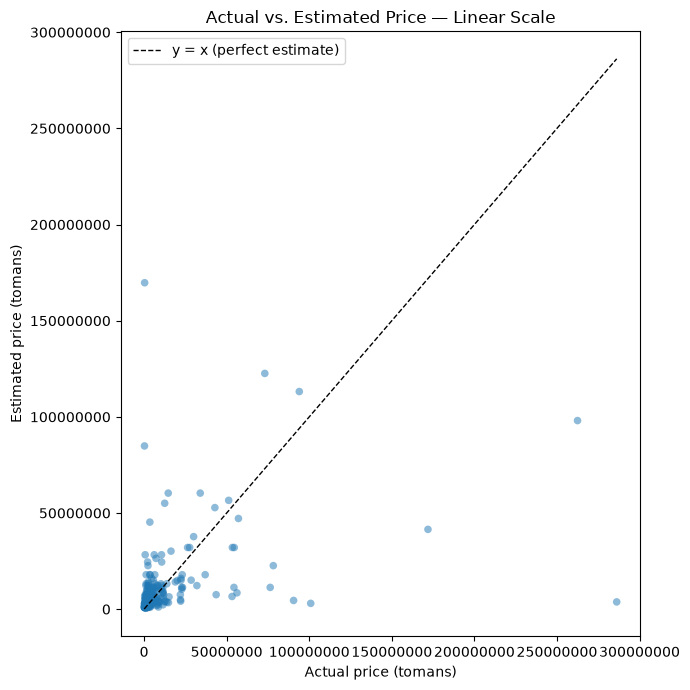

In [233]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(df["actual_price_tomans"], df["estimated_price_tomans"],
           alpha=0.5, edgecolors="none", s=30)

lo = min(df["actual_price_tomans"].min(), df["estimated_price_tomans"].min())
hi = max(df["actual_price_tomans"].max(), df["estimated_price_tomans"].max())
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="y = x (perfect estimate)")

ax.set_xlabel("Actual price (tomans)")
ax.set_ylabel("Estimated price (tomans)")
ax.set_title("Actual vs. Estimated Price — Linear Scale")
ax.legend()
ax.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()

## Log space

Same data, both axes log-scaled. Freelance project prices tend to span
a couple of orders of magnitude, so this view keeps cheap projects from
being crushed into the corner and makes relative (percentage) error
easier to eyeball — equal vertical distance from the `y = x` line now
means roughly equal relative error, not equal absolute error.

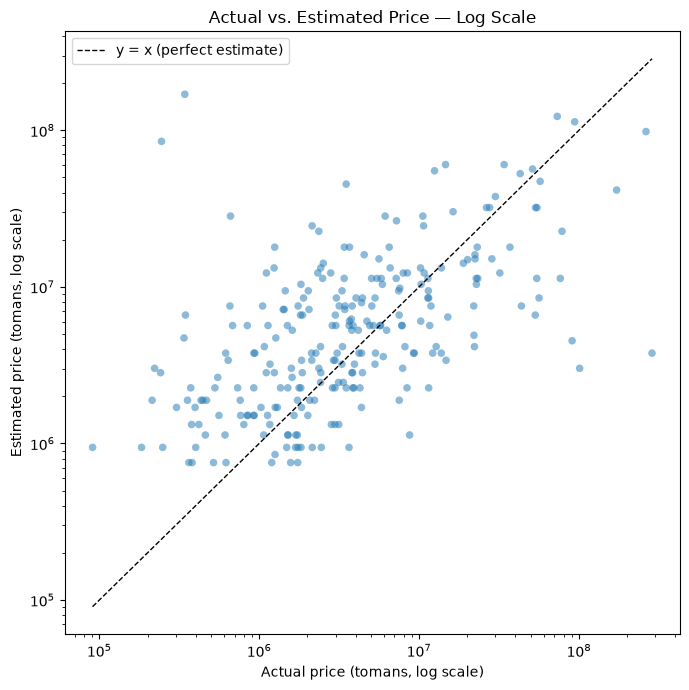

In [234]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(df["actual_price_tomans"], df["estimated_price_tomans"],
           alpha=0.5, edgecolors="none", s=30)

lo = min(df["actual_price_tomans"].min(), df["estimated_price_tomans"].min())
hi = max(df["actual_price_tomans"].max(), df["estimated_price_tomans"].max())
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="y = x (perfect estimate)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual price (tomans, log scale)")
ax.set_ylabel("Estimated price (tomans, log scale)")
ax.set_title("Actual vs. Estimated Price — Log Scale")
ax.legend()
plt.tight_layout()
plt.show()

## Error distribution (bonus)

Percentage error per project, sorted — a quick way to see how often the
estimator is close vs. wildly off, independent of absolute price.

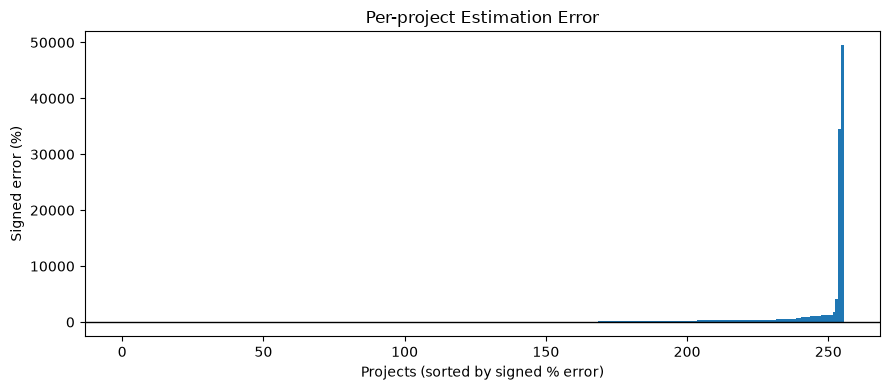

In [235]:
fig, ax = plt.subplots(figsize=(9, 4))

signed_pct_error = ((df["estimated_price_tomans"] - df["actual_price_tomans"])
                     / df["actual_price_tomans"] * 100).sort_values().reset_index(drop=True)

ax.bar(range(len(signed_pct_error)), signed_pct_error, width=1.0)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Projects (sorted by signed % error)")
ax.set_ylabel("Signed error (%)")
ax.set_title("Per-project Estimation Error")
plt.tight_layout()
plt.show()

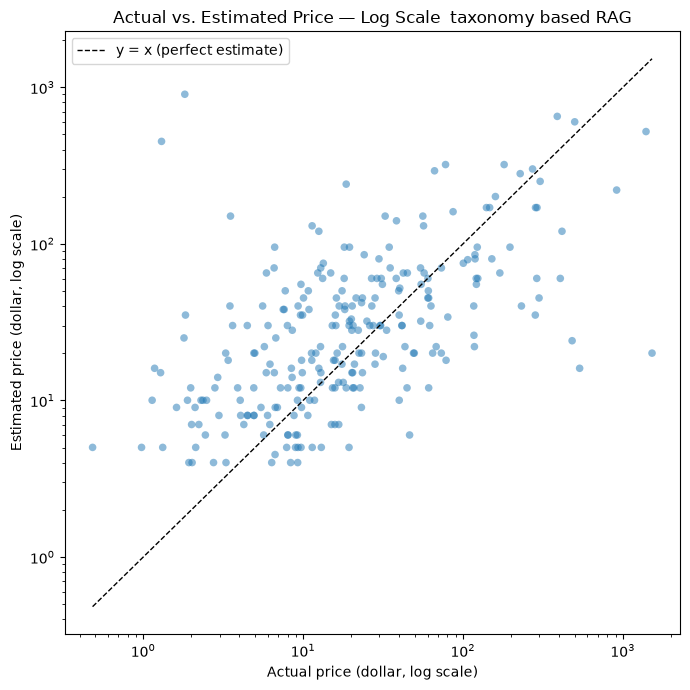

In [236]:
df["actual_price_tomans_m"] = df["actual_price_tomans"] / 188000
df["estimated_price_tomans_m"] = df["estimated_price_tomans"] / 188000

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(df["actual_price_tomans_m"], df["estimated_price_tomans_m"],
           alpha=0.5, edgecolors="none", s=30)

lo = min(df["actual_price_tomans_m"].min(), df["estimated_price_tomans_m"].min())
hi = max(df["actual_price_tomans_m"].max(), df["estimated_price_tomans_m"].max())
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="y = x (perfect estimate)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual price (dollar, log scale)")
ax.set_ylabel("Estimated price (dollar, log scale)")
ax.set_title("Actual vs. Estimated Price — Log Scale  taxonomy based RAG")
ax.legend()
plt.tight_layout()
plt.show()